# Statistical Analysis - House Price Prediction

This notebook performs statistical tests and analysis on the Ames Housing dataset to understand relationships between features and the target variable (Saleprice).

In [35]:
!pip install numpy pandas matplotlib seaborn scipy statsmodels


[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Data

In [37]:
df = pd.read_csv('../data/processed/cleaned_data.csv')
print(f"Data loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Data loaded with 1458 rows and 291 columns.


,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_COD,SaleType_New,SaleType_WD,SaleCondition_Abnorml,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Saleprice,is_luxury,is_crisis_year
0,1,18.144573,13.833054,7,3.991517,2003,2003,19.433175,144.117862,0.0,...,0,0,1,0,0,1,0,208501.0,0,1
1,2,20.673625,14.117918,6,6.000033,1976,1976,54.598150,181.719186,0.0,...,0,0,1,0,0,1,0,181501.0,0,0
2,3,18.668047,14.476512,7,3.991517,2001,2002,17.768840,110.441033,0.0,...,0,0,1,0,0,1,0,223501.0,0,1
3,4,17.249651,14.106196,7,3.991517,1915,1970,54.598150,61.795315,0.0,...,0,0,1,1,0,0,0,140001.0,0,0
4,5,21.314283,15.022008,8,3.991517,2000,2000,25.404164,136.624601,0.0,...,0,0,1,0,0,1,0,250001.0,0,1


## 2. Descriptive Statistics

In [38]:
print("Descriptive Statistics for Target Variable (Saleprice):")
print(df['Saleprice'].describe())

Descriptive Statistics for Target Variable (Saleprice):
count      1458.000000
mean     180933.919067
std       79495.055285
min       34901.000000
25%      129926.000000
50%      163001.000000
75%      214001.000000
max      755001.000000
Name: Saleprice, dtype: float64


## 3. Normality Test for Saleprice
Most statistical tests assume normality. Let's check if Saleprice follows a normal distribution.

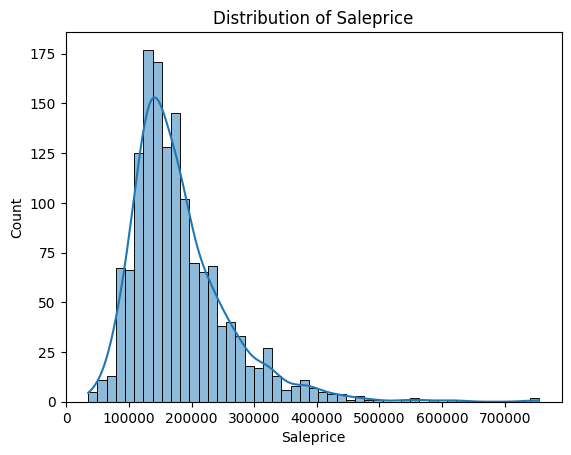

Shapiro-Wilk Test: Statistics=0.870, p-value=0.000
Sample does not look Gaussian (reject H0)


In [39]:
sns.histplot(df['Saleprice'], kde=True)
plt.title('Distribution of Saleprice')
plt.show()

# Shapiro-Wilk Test
stat, p = stats.shapiro(df['Saleprice'])
print(f'Shapiro-Wilk Test: Statistics={stat:.3f}, p-value={p:.3f}')
if p > 0.05:
    print('Sample looks Gaussian (fail to reject H0)')
else:
    print('Sample does not look Gaussian (reject H0)')

## 4. Correlation Analysis
Checking Pearson correlation for continuous variables.

In [40]:
correlations = df.select_dtypes(include=[np.number]).corr()['Saleprice'].sort_values(ascending=False)
print("Top Correlations with Saleprice:")
print(correlations.head(10))

Top Correlations with Saleprice:
Saleprice             1.000000
OverallQual           0.795774
GrLivArea             0.704396
GrLivArea_log_sq      0.700748
GrLivArea_log         0.697598
Total_Home_Quality    0.686171
TotalBsmtSF           0.653921
GarageCars_log_sq     0.651931
GarageCars            0.641047
Total_Bathrooms       0.637336
Name: Saleprice, dtype: float64


## 5. Hypothesis Testing: ANOVA
Does the Overall Quality have a significant impact on Saleprice?

In [41]:
# Analysis of Variance (ANOVA)
model = ols('Saleprice ~ C(OverallQual)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# Using .iloc[0] to avoid KeyError with labels
p_value = anova_table['PR(>F)'].iloc[0]
if p_value < 0.05:
    print(f"\nOverall Quality has a statistically significant effect on Saleprice (p-value: {p_value:.4e}).")
else:
    print(f"\nOverall Quality does not have a significant effect on Saleprice (p-value: {p_value:.4f}).")

                      sum_sq      df           F  PR(>F)
C(OverallQual)  6.459191e+12     9.0  378.133458     0.0
Residual        2.748268e+12  1448.0         NaN     NaN

Overall Quality has a statistically significant effect on Saleprice (p-value: 0.0000e+00).
